In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("andrewmvd/pediatric-pneumonia-chest-xray")

# print("Path to dataset files:", path)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sajidhussain4540/lus-ultrasound-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sajidhussain4540/lus-ultrasound-dataset


In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# print("Path to dataset files:", path)

In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

# print("Path to dataset files:", path)

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("ahmedhaytham/chest-xray-images-pneumonia-with-new-class")

# print("Path to dataset files:", path)

In [1]:
# Import Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Paths to dataset
train_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset"
normal_dir = os.path.join(train_dir, "Normal")
pneumonia_dir = os.path.join(train_dir, "Pneumonia")
print(train_dir)

/kaggle/input/covid19-data/COVID-19_Radiography_Dataset


In [4]:
import os

# Dataset paths
train_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset"
normal_dir = os.path.join(train_dir, "Normal")
pneumonia_dir = os.path.join(train_dir, "Pneumonia")

def count_images_recursive(folder_path):
    image_extensions = (".png", ".jpg", ".jpeg")
    count = 0
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

# Count images recursively
normal_count = count_images_recursive(normal_dir)
pneumonia_count = count_images_recursive(pneumonia_dir)
total_images = normal_count + pneumonia_count

# Print results
print("Dataset Root Path :", train_dir)
print("Normal Path       :", normal_dir)
print("Pneumonia Path    :", pneumonia_dir)
print("-" * 40)
print(f"Normal images     : {normal_count}")
print(f"Pneumonia images  : {pneumonia_count}")
print(f"Total images      : {total_images}")


Dataset Root Path : /kaggle/input/covid19-data/COVID-19_Radiography_Dataset
Normal Path       : /kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Normal
Pneumonia Path    : /kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Pneumonia
----------------------------------------
Normal images     : 1345
Pneumonia images  : 1345
Total images      : 2690


In [3]:
# -------------------- Data Preprocessing & Augmentation --------------------
# Transformations for training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),        # Resize images to 224x224
    transforms.RandomHorizontalFlip(),    # Data augmentation
    transforms.RandomRotation(10),
    transforms.ToTensor(),                # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # Imagenet normalization
])


In [4]:
# Transformations for validation/test
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
# -------------------- Dataset & DataLoader --------------------
# Using ImageFolder (expects subfolders per class)
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

# Optionally split dataset into train and validation
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [6]:
# -------------------- Model Definition --------------------
# Use pre-trained ResNet50 for transfer learning
model = models.resnet50(pretrained=True)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]


In [7]:
# Freeze initial layers (optional)
for param in model.parameters():
    param.requires_grad = False

In [8]:
# Modify the final fully connected layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # 2 classes: Normal and Pneumonia
model = model.to(device)


In [9]:
# -------------------- Loss & Optimizer --------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

In [10]:
# -------------------- Training Loop with History --------------------
num_epochs = 10
best_val_acc = 0.0

# Lists to store history
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
    
    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.double() / train_size
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_loss = val_running_loss / val_size
    val_acc = val_corrects.double() / val_size
    
    # Save history
    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc.item())
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc.item())
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_covid19_resnet50.pth")


Epoch 1/10 | Train Loss: 0.5912 | Train Acc: 0.7519 | Val Loss: 0.4842 | Val Acc: 0.9089
Epoch 2/10 | Train Loss: 0.4596 | Train Acc: 0.8838 | Val Loss: 0.3945 | Val Acc: 0.9033
Epoch 3/10 | Train Loss: 0.3942 | Train Acc: 0.8954 | Val Loss: 0.3456 | Val Acc: 0.9182
Epoch 4/10 | Train Loss: 0.3530 | Train Acc: 0.8996 | Val Loss: 0.3047 | Val Acc: 0.9182
Epoch 5/10 | Train Loss: 0.3258 | Train Acc: 0.9080 | Val Loss: 0.2819 | Val Acc: 0.9201
Epoch 6/10 | Train Loss: 0.3038 | Train Acc: 0.9112 | Val Loss: 0.2773 | Val Acc: 0.9312
Epoch 7/10 | Train Loss: 0.2880 | Train Acc: 0.9057 | Val Loss: 0.2533 | Val Acc: 0.9238
Epoch 8/10 | Train Loss: 0.2829 | Train Acc: 0.9122 | Val Loss: 0.2406 | Val Acc: 0.9424
Epoch 9/10 | Train Loss: 0.2669 | Train Acc: 0.9178 | Val Loss: 0.2277 | Val Acc: 0.9405
Epoch 10/10 | Train Loss: 0.2521 | Train Acc: 0.9178 | Val Loss: 0.2282 | Val Acc: 0.9312


✅ Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92       276
   Pneumonia       0.90      0.94      0.92       262

    accuracy                           0.92       538
   macro avg       0.92      0.92      0.92       538
weighted avg       0.92      0.92      0.92       538

✅ Validation Accuracy: 0.9219


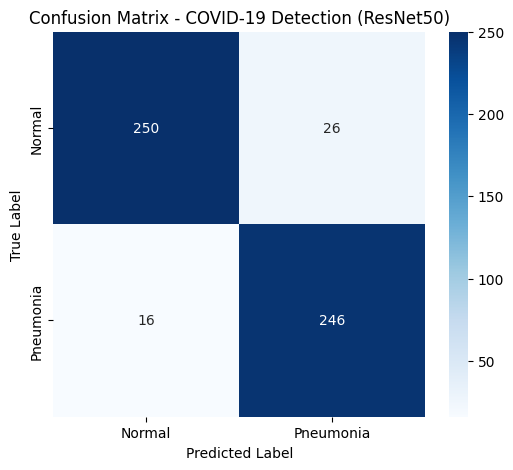

In [28]:
# # -------------------- Evaluation on Validation Set --------------------
# model.load_state_dict(torch.load("/kaggle/working/best_covid19_resnet50.pth"))
# model.eval()

# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for inputs, labels in val_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
#         outputs = model(inputs)
#         _, preds = torch.max(outputs, 1)
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# print("Classification Report:")
# print(classification_report(all_labels, all_preds, target_names=train_dataset.dataset.classes))

# -------------------- Evaluation on Validation Set --------------------
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define same ResNet50 model
from torchvision.models import resnet50, ResNet50_Weights
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# Load trained weights
model.load_state_dict(torch.load("/kaggle/working/best_covid19_resnet50.pth", map_location=device))
model.eval()

# Evaluate on validation data
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------------------- Metrics --------------------
# Extract class names properly
class_names = val_dataset.dataset.classes

print("✅ Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

acc = accuracy_score(all_labels, all_preds)
print(f"✅ Validation Accuracy: {acc:.4f}")

# -------------------- Confusion Matrix --------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - COVID-19 Detection (ResNet50)")
plt.show()


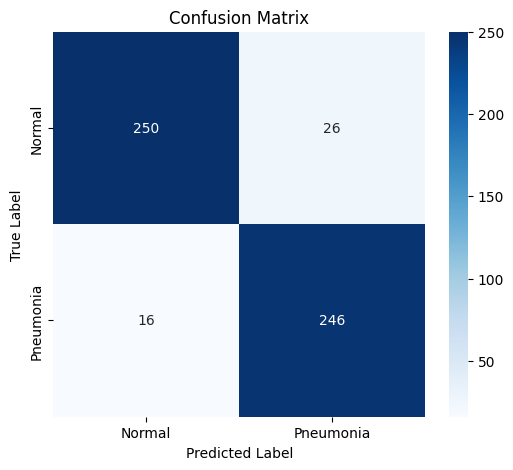

✅ Confusion matrix saved successfully at: /kaggle/working/confusion_matrix.png


In [29]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Define class names (should match your dataset folders)
class_names = ['Normal', 'Pneumonia']

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')

# Save and show
save_path = os.path.join("/kaggle/working", "confusion_matrix.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Confusion matrix saved successfully at: {save_path}")


In [30]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Collect ground truth & predictions
y_true, y_pred, y_prob = [], [], []
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1 (Pneumonia)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


In [32]:
# Assuming you stored history during training like train_acc, val_acc, train_loss, val_loss

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_acc_history, label="Train Accuracy")
plt.plot(range(1, num_epochs+1), val_acc_history, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("/kaggle/working/accuracy_curve.png")
plt.close()

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_loss_history, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_loss_history, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("/kaggle/working/loss_curve.png")
plt.close()


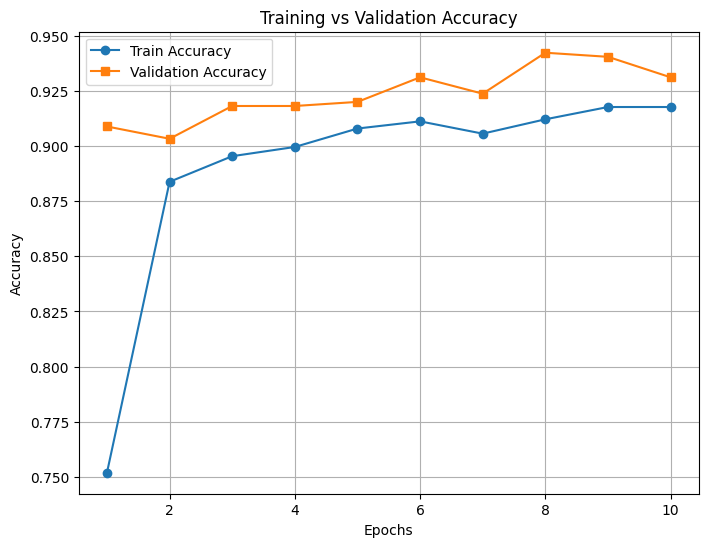

In [33]:
# plt.plot(range(1, num_epochs+1), train_acc_history, label="Train Accuracy")
# plt.plot(range(1, num_epochs+1), val_acc_history, label="Validation Accuracy")


import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), train_acc_history, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs + 1), val_acc_history, label="Validation Accuracy", marker='s')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Save and show
plt.savefig("/kaggle/working/accuracy_plot.png", dpi=300, bbox_inches='tight')
plt.show()


In [34]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.savefig("/kaggle/working/roc_curve.png")
plt.close()


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_and_save_roc_curve(y_true, y_prob, save_path="/kaggle/working/roc_curve.png"):
    """
    Plot and save ROC Curve.
    Args:
        y_true: Ground truth labels (0 or 1)
        y_prob: Predicted probabilities for class 1
        save_path: Path to save ROC curve image
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="red", linestyle="--", lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title("Receiver Operating Characteristic (ROC)")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.6)

    # Save and show
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"ROC curve saved at: {save_path}")


In [36]:
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="green")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.savefig("/kaggle/working/precision_recall.png")
plt.close()


In [37]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

# Calculate per-class metrics
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

# Get class names
classes = ['Normal', 'Pneumonia']

# Plot F1 scores
plt.figure(figsize=(8,6))
plt.bar(classes, f1, color=["skyblue","lightcoral"])
plt.xlabel("Classes")
plt.ylabel("F1 Score")
plt.title("F1-Score per Class")
plt.savefig("/kaggle/working/f1_score.png")
plt.close()


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Directory to save batch images
save_dir = "/kaggle/working/pred_vs_actual_batches"
os.makedirs(save_dir, exist_ok=True)

def save_batch_predictions(model, dataloader, classes, max_images_per_batch=32):
    model.eval()
    
    batch_num = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            # Limit number of images to plot per batch
            batch_size = min(inputs.size(0), max_images_per_batch)
            
            fig, axes = plt.subplots(4, 8, figsize=(24, 12))  # 32 images per batch
            axes = axes.flatten()
            
            for i in range(batch_size):
                img = inputs[i].cpu().permute(1, 2, 0).numpy()
                img = np.clip(img * np.array([0.229, 0.224, 0.225]) + 
                               np.array([0.485, 0.456, 0.406]), 0, 1)  # de-normalize
                
                actual = classes[labels[i].item()]
                predicted = classes[preds[i].item()]
                
                axes[i].imshow(img)
                axes[i].axis("off")
                axes[i].set_title(f"Pred: {predicted}\nActual: {actual}",
                                  color="green" if predicted == actual else "red", fontsize=10)
            
            # Hide unused axes if batch < 32
            for j in range(batch_size, len(axes)):
                axes[j].axis("off")
            
            plt.tight_layout()
            batch_path = os.path.join(save_dir, f"batch_{batch_num+1}.png")
            plt.savefig(batch_path)
            plt.close()
            
            print(f"Saved batch {batch_num+1} to {batch_path}")
            batch_num += 1

# Run
classes = ['Normal', 'Pneumonia']
save_batch_predictions(model, val_loader, classes)


Saved batch 1 to /kaggle/working/pred_vs_actual_batches/batch_1.png
Saved batch 2 to /kaggle/working/pred_vs_actual_batches/batch_2.png
Saved batch 3 to /kaggle/working/pred_vs_actual_batches/batch_3.png
Saved batch 4 to /kaggle/working/pred_vs_actual_batches/batch_4.png
Saved batch 5 to /kaggle/working/pred_vs_actual_batches/batch_5.png
Saved batch 6 to /kaggle/working/pred_vs_actual_batches/batch_6.png
Saved batch 7 to /kaggle/working/pred_vs_actual_batches/batch_7.png
Saved batch 8 to /kaggle/working/pred_vs_actual_batches/batch_8.png
Saved batch 9 to /kaggle/working/pred_vs_actual_batches/batch_9.png
Saved batch 10 to /kaggle/working/pred_vs_actual_batches/batch_10.png
Saved batch 11 to /kaggle/working/pred_vs_actual_batches/batch_11.png
Saved batch 12 to /kaggle/working/pred_vs_actual_batches/batch_12.png
Saved batch 13 to /kaggle/working/pred_vs_actual_batches/batch_13.png
Saved batch 14 to /kaggle/working/pred_vs_actual_batches/batch_14.png
Saved batch 15 to /kaggle/working/pred

In [11]:
# -------------------- Libraries --------------------
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# -------------------- Device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [12]:
# -------------------- Dataset Paths --------------------
data_dir = "/kaggle/input/datasets/sajidhussain4540/lus-ultrasound-dataset/LUS Ultrasound Images"
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

# -------------------- Data Preprocessing --------------------
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [6]:
import os

# -------------------- Dataset Path --------------------
data_dir = "/kaggle/input/datasets/sajidhussain4540/lus-ultrasound-dataset/LUS Ultrasound Images"

def count_images_recursive(folder_path):
    image_extensions = (".png", ".jpg", ".jpeg")
    count = 0
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

# -------------------- Class-wise Count --------------------
normal_count = count_images_recursive(os.path.join(data_dir, "train", "NORMAL")) + \
               count_images_recursive(os.path.join(data_dir, "test", "NORMAL"))

pneumonia_count = count_images_recursive(os.path.join(data_dir, "train", "PNEUMONIA")) + \
                  count_images_recursive(os.path.join(data_dir, "test", "PNEUMONIA"))

total_images = normal_count + pneumonia_count

# -------------------- Print Results --------------------
print("Dataset Path :", data_dir)
print("-" * 40)
print(f"Normal images     : {normal_count}")
print(f"Pneumonia images  : {pneumonia_count}")
print(f"Total images      : {total_images}")


Dataset Path : /kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia
----------------------------------------
Normal images     : 1583
Pneumonia images  : 4273
Total images      : 5856


In [13]:
# -------------------- Datasets --------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
class_names = train_dataset.classes

In [14]:
# -------------------- Handle Imbalance --------------------
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for label in train_dataset.targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Classes:", class_names, " | Counts:", class_counts)

Classes: ['NORMAL', 'PNEUMONIA']  | Counts: [1349 3883]


In [15]:
# -------------------- Vision Transformer --------------------
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2)

# Freeze early layers (fine-tuning trick)
for name, param in model.named_parameters():
    if "head" not in name:   # keep classification head trainable
        param.requires_grad = False

model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [16]:
# -------------------- Loss & Optimizer --------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [17]:
# # -------------------- Training Loop --------------------
# num_epochs = 10
# best_acc, patience, patience_counter = 0.0, 5, 0

# for epoch in range(num_epochs):
#     # ---- Training ----
#     model.train()
#     running_loss, running_corrects = 0.0, 0
    
#     loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
#     for inputs, labels in loop:
#         inputs, labels = inputs.to(device), labels.to(device)

#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item() * inputs.size(0)
#         _, preds = torch.max(outputs, 1)
#         running_corrects += torch.sum(preds == labels.data)
        
#         loop.set_postfix({"Batch Loss": loss.item()})
    
#     epoch_loss = running_loss / len(train_dataset)
#     epoch_acc = running_corrects.double() / len(train_dataset)




# -------------------- Training Loop --------------------
num_epochs = 10
best_acc, patience, patience_counter = 0.0, 5, 0

# containers for plotting later
train_losses, val_losses = [], []
train_accs, val_accs = [], []
all_labels, all_preds, all_probs = [], [], []  # for eval curves

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss, running_corrects = 0.0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        
        loop.set_postfix({"Batch Loss": loss.item()})
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc.item())

    # ---- Validation ----
    model.eval()
    val_loss, val_corrects = 0.0, 0
    all_labels, all_preds, all_probs = [], [], []  # reset each epoch

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

            # store for evaluation later
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, 1)[:,1].cpu().numpy())

    val_epoch_loss = val_loss / len(test_dataset)
    val_epoch_acc = val_corrects.double() / len(test_dataset)
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc.item())

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"| Train Loss {epoch_loss:.4f}, Acc {epoch_acc:.4f} "
          f"| Val Loss {val_epoch_loss:.4f}, Acc {val_epoch_acc:.4f}")



Epoch 1/10: 100%|██████████| 164/164 [01:22<00:00,  1.99it/s, Batch Loss=0.448]


Epoch 1/10 | Train Loss 0.4683, Acc 0.8375 | Val Loss 0.4706, Acc 0.8045


Epoch 2/10: 100%|██████████| 164/164 [01:14<00:00,  2.19it/s, Batch Loss=0.261]


Epoch 2/10 | Train Loss 0.3114, Acc 0.9142 | Val Loss 0.4144, Acc 0.8333


Epoch 3/10: 100%|██████████| 164/164 [01:10<00:00,  2.34it/s, Batch Loss=0.32] 


...

Epoch 8/10 | Train Loss 0.1803, Acc 0.9411 | Val Loss 0.2965, Acc 0.8750


Epoch 9/10: 100%|██████████| 164/164 [01:09<00:00,  2.37it/s, Batch Loss=0.24]  


Epoch 9/10 | Train Loss 0.1692, Acc 0.9427 | Val Loss 0.2954, Acc 0.8734


Epoch 10/10: 100%|██████████| 164/164 [01:10<00:00,  2.31it/s, Batch Loss=0.37]  


Epoch 10/10 | Train Loss 0.1746, Acc 0.9398 | Val Loss 0.2871, Acc 0.8846


In [22]:
# ---- Validation ----
model.eval()
val_loss, val_corrects = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        val_corrects += torch.sum(preds == labels.data)

val_epoch_loss = val_loss / len(test_dataset)
val_acc = val_corrects.double() / len(test_dataset)
scheduler.step()

print(f"Epoch {epoch+1}: Train Loss {epoch_loss:.4f}, Train Acc {epoch_acc:.4f}, "
      f"Val Loss {val_epoch_loss:.4f}, Val Acc {val_acc:.4f}")


Epoch 10: Train Loss 0.1746, Train Acc 0.9398, Val Loss 0.2871, Val Acc 0.8846


In [23]:
# -------------------- Save the best model --------------------
model_save_path = "pediatric_pneumonia_vit.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to pediatric_pneumonia_vit.pth



Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.83      0.84       234
   Pneumonia       0.90      0.92      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.87      0.88       624
weighted avg       0.88      0.88      0.88       624



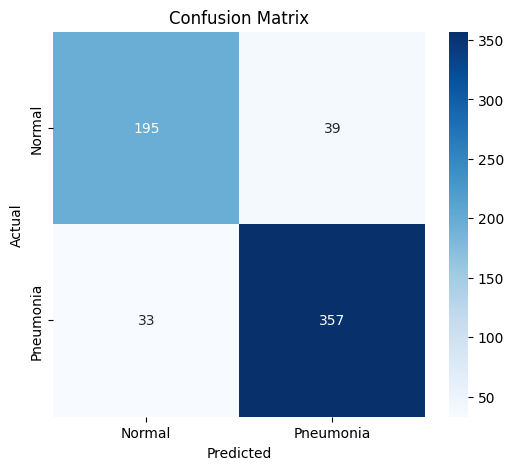

In [42]:
# # -------------------- Evaluation --------------------
# model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth"))
# model.eval()

# all_preds, all_labels = [], []
# with torch.no_grad():
#     for inputs, labels in test_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
#         outputs = model(inputs)
#         _, preds = torch.max(outputs, 1)
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------- Evaluation --------------------
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Recreate the same ViT model architecture
model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
model = model.to(device)

# Load the saved checkpoint
checkpoint_path = "/kaggle/working/pediatric_pneumonia_vit.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Prepare lists to store predictions and labels
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------------------- Classification Report --------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------- Confusion Matrix --------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


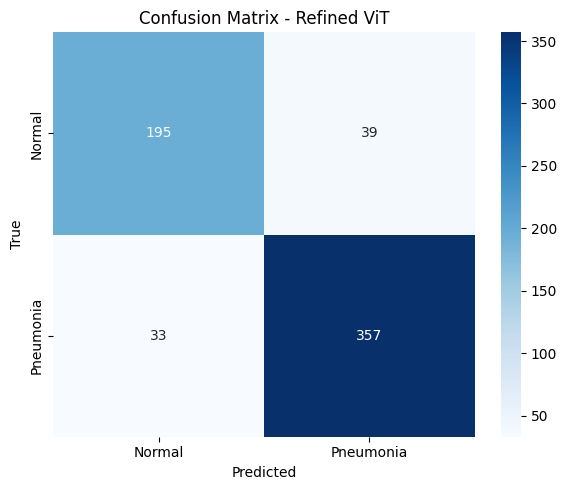

In [47]:
# Plot and save
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Refined ViT")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()  # ensures labels/titles fit

# Save as PNG before show
plt.savefig("/kaggle/working/confusion_matrix_vit.png", dpi=300)

# Show the plot
plt.show()


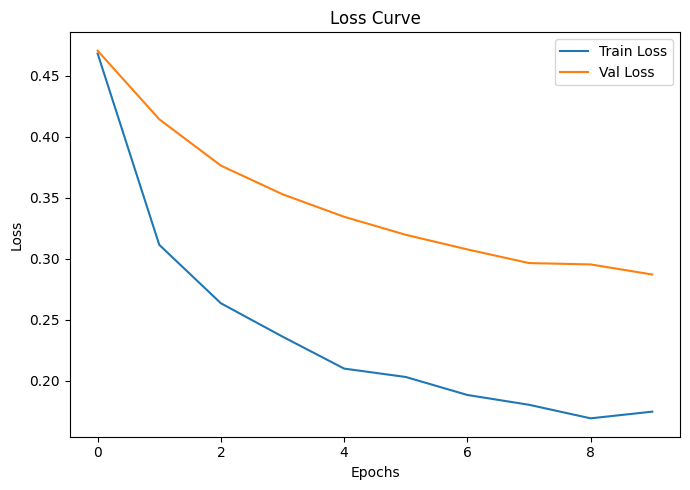

In [48]:
# -------------------- Plot Loss Curve --------------------
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()  # ensure labels/titles fit

# Save as PNG BEFORE showing
plt.savefig("/kaggle/working/Vit_Loss_Curve.png", dpi=300)

# Show the plot
plt.show()
plt.close()


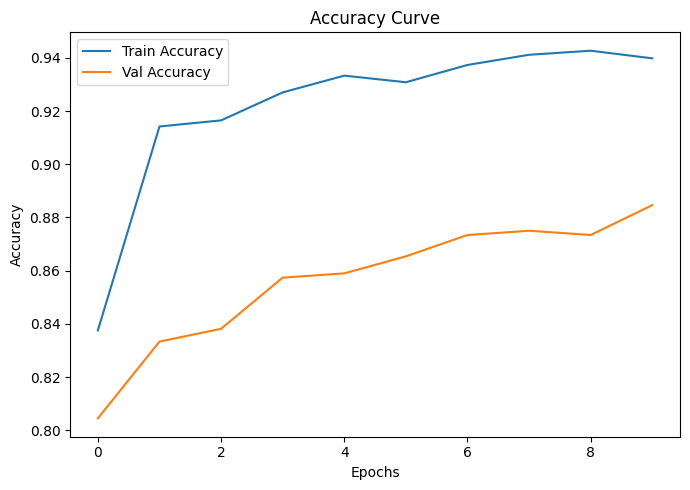

In [49]:
# -------------------- Plot Accuracy Curve --------------------
plt.figure(figsize=(7,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()  # ensure everything fits

# Save as PNG BEFORE showing
plt.savefig("/kaggle/working/Vit_Accuracy_Curve.png", dpi=300)

# Show the plot
plt.show()
plt.close()


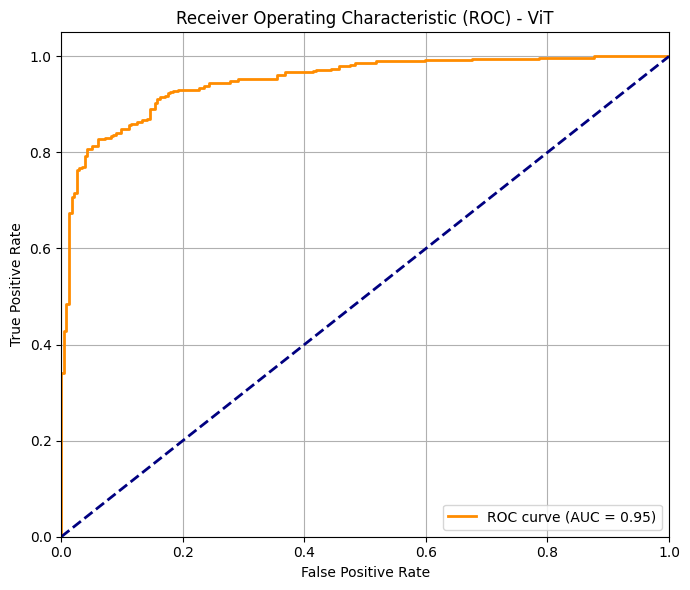

In [50]:
# -------------------- ROC Curve & AUC --------------------
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)  # all_probs = model probabilities for class 1
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - ViT')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

# Save as PNG
plt.savefig("/kaggle/working/Vit_ROC_Curve.png", dpi=300)

# Show the plot
plt.show()
plt.close()


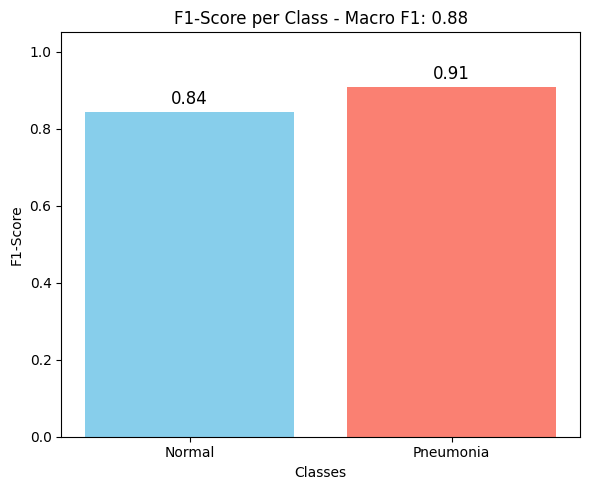

In [51]:
# -------------------- F1 Score Curve --------------------
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Compute F1-score per class
f1_per_class = f1_score(all_labels, all_preds, average=None)  # per class
macro_f1 = f1_score(all_labels, all_preds, average='macro')   # overall macro F1

# Plot F1-score per class
plt.figure(figsize=(6,5))
bars = plt.bar(class_names, f1_per_class, color=['skyblue', 'salmon'])
plt.ylim(0, 1.05)

# Annotate bars with scores
for bar, score in zip(bars, f1_per_class):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{score:.2f}", ha='center', fontsize=12)

plt.title(f"F1-Score per Class - Macro F1: {macro_f1:.2f}")
plt.ylabel("F1-Score")
plt.xlabel("Classes")
plt.tight_layout()

# Save as PNG
plt.savefig("/kaggle/working/Vit_F1_Score.png", dpi=300)

# Show the plot
plt.show()
plt.close()


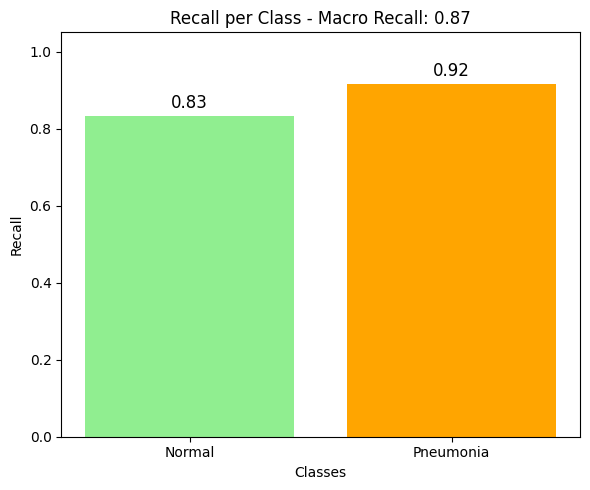

In [52]:
# -------------------- Recall Curve --------------------
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

# Compute recall per class
recall_per_class = recall_score(all_labels, all_preds, average=None)  # per class
macro_recall = recall_score(all_labels, all_preds, average='macro')   # overall macro recall

# Plot Recall per class
plt.figure(figsize=(6,5))
bars = plt.bar(class_names, recall_per_class, color=['lightgreen', 'orange'])
plt.ylim(0, 1.05)

# Annotate bars with recall scores
for bar, score in zip(bars, recall_per_class):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{score:.2f}", ha='center', fontsize=12)

plt.title(f"Recall per Class - Macro Recall: {macro_recall:.2f}")
plt.ylabel("Recall")
plt.xlabel("Classes")
plt.tight_layout()

# Save as PNG
plt.savefig("/kaggle/working/Vit_Recall_Curve.png", dpi=300)

# Show the plot
plt.show()
plt.close()


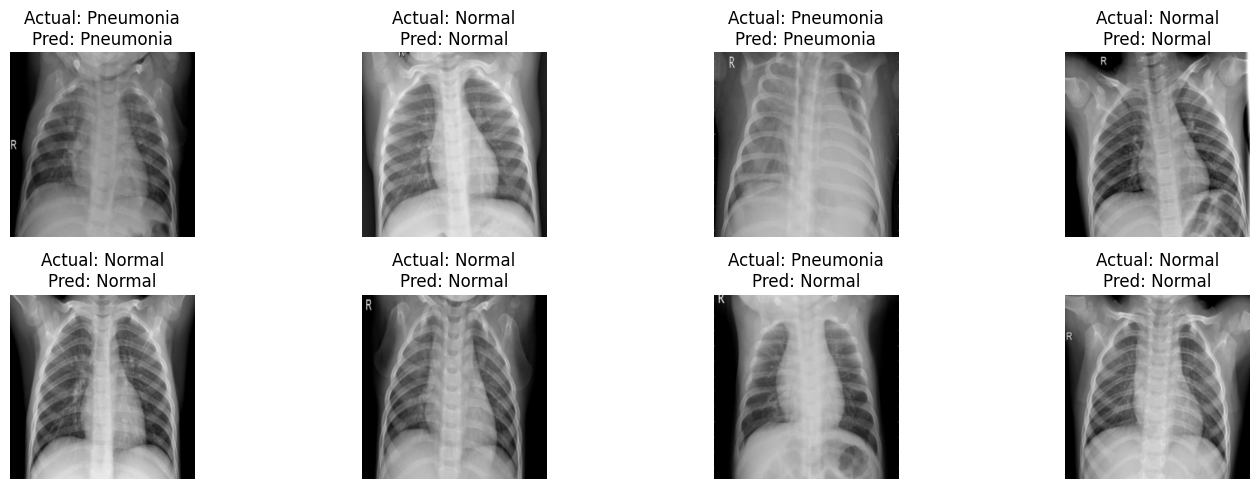

In [61]:
# -------------------- Actual vs Predicted Samples --------------------
import matplotlib.pyplot as plt
import numpy as np
import random
from torchvision.utils import make_grid

# Number of random samples to display
num_samples = 8

# Randomly select indices from test dataset
indices = random.sample(range(len(test_dataset)), num_samples)

plt.figure(figsize=(15,5))

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)  # add batch dimension
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
    
    # Convert tensor image to numpy for plotting
    img_np = img.permute(1,2,0).numpy()  # C,H,W -> H,W,C
    img_np = (img_np * 0.5) + 0.5  # unnormalize

    plt.subplot(2, num_samples//2, i+1)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(f"Actual: {class_names[label]}\nPred: {class_names[pred.item()]}", fontsize=12)

plt.tight_layout()

# Save figure as PNG
plt.savefig("/kaggle/working/Actual_vs_Predicted_Samples.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Ensemble Model

In [62]:
import timm

# -------------------- Load ViT Model --------------------
vit_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model.to(device)
vit_model.eval()

# -------------------- Load ResNet50 Model --------------------
resnet50 = models.resnet50(pretrained=False)
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, 2)
resnet50.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet50.to(device)
resnet50.eval()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [63]:
import torch
import torch.nn as nn
import timm
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Load Trained Models --------------------
# 1. Load ResNet50 (Ultrasound)
resnet_model = models.resnet50(pretrained=False)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)  # match 2 classes
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model.to(device)
resnet_model.eval()

# 2. Load ViT (CXR)
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("pediatric_pneumonia_vit.pth", map_location=device))
vit_model.to(device)
vit_model.eval()

# -------------------- Ensemble Function --------------------
def ensemble_predict(x_resnet, x_vit, w1=0.5, w2=0.5):
    """
    w1 = weight for ResNet (Ultrasound)
    w2 = weight for ViT (CXR)
    """
    with torch.no_grad():
        # Get softmax probabilities
        resnet_probs = torch.softmax(resnet_model(x_resnet), dim=1)
        vit_probs = torch.softmax(vit_model(x_vit), dim=1)
        
        # Weighted average fusion
        combined_probs = (w1 * resnet_probs + w2 * vit_probs) / (w1 + w2)
        preds = combined_probs.argmax(dim=1)
        
    return preds, combined_probs

# -------------------- Example Usage --------------------
# Suppose you have:
#   batch_x_resnet: Ultrasound batch (B,3,224,224)
#   batch_x_vit: CXR batch (B,3,224,224)

# preds, probs = ensemble_predict(batch_x_resnet.to(device), batch_x_vit.to(device), w1=0.6, w2=0.4)
# print("Predicted:", preds)


In [64]:
import torch
import torch.nn.functional as F
import timm
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Load Models --------------------
# ViT (CXR model)
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model.to(device)
vit_model.eval()

# ResNet50 (Ultrasound model)
resnet_model = models.resnet50(weights=None)
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 2)  # adjust for binary
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model.to(device)
resnet_model.eval()

print("✅ Models Loaded Successfully!")

# -------------------- Ensemble Function --------------------
def ensemble_predict(img, w_vit=0.5, w_resnet=0.5):
    """
    img: single input tensor [1, 3, 224, 224]
    w_vit, w_resnet: weights for ensemble fusion
    """
    with torch.no_grad():
        # Model outputs
        out_vit = vit_model(img)
        out_resnet = resnet_model(img)

        # Convert logits → softmax probs
        probs_vit = F.softmax(out_vit, dim=1)
        probs_resnet = F.softmax(out_resnet, dim=1)

        # Weighted fusion
        probs_final = (w_vit * probs_vit) + (w_resnet * probs_resnet)

        # Predicted class
        pred_class = probs_final.argmax(dim=1).item()

    return pred_class, probs_final.cpu().numpy()

✅ Models Loaded Successfully!


In [65]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== Ensemble Model =====
class EnsembleModel(nn.Module):
    def __init__(self, model_cxr, model_us, weight_cxr=0.5, weight_us=0.5):
        super(EnsembleModel, self).__init__()
        self.model_cxr = model_cxr
        self.model_us = model_us
        self.weight_cxr = weight_cxr
        self.weight_us = weight_us
    
    def forward(self, x_cxr, x_us):
        with torch.no_grad():
            out_cxr = torch.softmax(self.model_cxr(x_cxr), dim=1)
            out_us = torch.softmax(self.model_us(x_us), dim=1)
        return self.weight_cxr * out_cxr + self.weight_us * out_us

# ===== Evaluation Function =====
def evaluate_ensemble(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for (images_cxr, images_us, labels) in dataloader:
            images_cxr, images_us, labels = images_cxr.to(device), images_us.to(device), labels.to(device)
            
            outputs = model(images_cxr, images_us)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ===== Metrics =====
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n✅ Ensemble Accuracy: {acc:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    print("\n🔎 Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

# ===== Usage =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load your trained models
resnet_model = torch.load("best_covid19_resnet50.pth", map_location=device)
vit_model = torch.load("pediatric_pneumonia_vit.pth", map_location=device)

# Wrap them in ensemble
ensemble_model = EnsembleModel(resnet_model, vit_model, weight_cxr=0.5, weight_us=0.5).to(device)

# Evaluate
evaluate_ensemble(ensemble_model, test_loader, device)


ValueError: not enough values to unpack (expected 3, got 2)

In [66]:
import timm
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Recreate ResNet50 for CXR ----
resnet_model = timm.create_model("resnet50", pretrained=False, num_classes=2)
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()

# ---- Recreate ViT for Pediatric Pneumonia ----
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [67]:
def evaluate_ensemble_singleloader(model1, model2, dataloader, device, w1=0.5, w2=0.5):
    all_preds, all_labels = [], []
    model1.eval(), model2.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            out1 = torch.softmax(model1(images), dim=1)
            out2 = torch.softmax(model2(images), dim=1)

            outputs = w1 * out1 + w2 * out2
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n✅ Ensemble Accuracy: {acc:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    print("\n🔎 Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

# Example usage:
evaluate_ensemble_singleloader(vit_model, resnet_model, test_loader, device, w1=0.6, w2=0.4)



✅ Ensemble Accuracy: 0.8077

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9524    0.5128    0.6667       234
           1     0.7711    0.9846    0.8649       390

    accuracy                         0.8077       624
   macro avg     0.8617    0.7487    0.7658       624
weighted avg     0.8391    0.8077    0.7905       624


🔎 Confusion Matrix:
[[120 114]
 [  6 384]]


In [68]:
import timm
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Recreate ResNet50 ----
resnet_model = timm.create_model("resnet50", pretrained=False, num_classes=2)
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()

# ---- Recreate ViT ----
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()


# -----------------------------
# Collect predictions from both models
# -----------------------------
def collect_probs(model, dataloader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            out = torch.softmax(model(images), dim=1)
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_probs), np.array(all_labels)

probs_resnet, y_true = collect_probs(resnet_model, test_loader)
probs_vit, _ = collect_probs(vit_model, test_loader)


# -----------------------------
# Grid Search for Best Weights
# -----------------------------
best_acc, best_w1, best_w2 = 0, 0, 0
for w1 in np.arange(0, 1.05, 0.05):   # 0.00 → 1.00 step 0.05
    w2 = 1 - w1
    ensemble_probs = (w1 * probs_resnet) + (w2 * probs_vit)
    preds = np.argmax(ensemble_probs, axis=1)
    acc = accuracy_score(y_true, preds)
    if acc > best_acc:
        best_acc, best_w1, best_w2 = acc, w1, w2

print(f"\n🔥 Best Weights: ResNet={best_w1:.2f}, ViT={best_w2:.2f}, Accuracy={best_acc:.4f}")

# -----------------------------
# Final Evaluation
# -----------------------------
final_probs = (best_w1 * probs_resnet) + (best_w2 * probs_vit)
final_preds = np.argmax(final_probs, axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_true, final_preds, digits=4))

print("\n🔎 Confusion Matrix:")
print(confusion_matrix(y_true, final_preds))



🔥 Best Weights: ResNet=0.05, ViT=0.95, Accuracy=0.8862

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.8655    0.8248    0.8446       234
           1     0.8978    0.9231    0.9102       390

    accuracy                         0.8862       624
   macro avg     0.8816    0.8739    0.8774       624
weighted avg     0.8856    0.8862    0.8856       624


🔎 Confusion Matrix:
[[193  41]
 [ 30 360]]


In [69]:
import timm
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Recreate ResNet50 ----
resnet_model = timm.create_model("resnet50", pretrained=False, num_classes=2)
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()

# ---- Recreate ViT ----
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()


# -----------------------------
# Collect predictions (softmax probs)
# -----------------------------
def collect_probs(model, dataloader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            out = torch.softmax(model(images), dim=1)
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_probs), np.array(all_labels)


# Collect outputs from both models
probs_resnet, y_true = collect_probs(resnet_model, test_loader)
probs_vit, _ = collect_probs(vit_model, test_loader)

# -----------------------------
# Stacking Ensemble (Meta-Learner)
# -----------------------------
# Feature matrix: concatenate outputs from both models
X = np.hstack([probs_resnet, probs_vit])   # shape = (n_samples, 4)
y = y_true

# Split into train/validation sets for meta-classifier
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Logistic Regression as meta-classifier
meta_clf = LogisticRegression(max_iter=500)
meta_clf.fit(X_train, y_train)

# Predict on validation
y_pred = meta_clf.predict(X_val)

# -----------------------------
# Final Evaluation
# -----------------------------
acc = accuracy_score(y_val, y_pred)
print(f"\n✅ Stacking Ensemble Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_val, y_pred, digits=4))

print("\n🔎 Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))



✅ Stacking Ensemble Accuracy: 0.8880

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.8511    0.8511    0.8511        47
           1     0.9103    0.9103    0.9103        78

    accuracy                         0.8880       125
   macro avg     0.8807    0.8807    0.8807       125
weighted avg     0.8880    0.8880    0.8880       125


🔎 Confusion Matrix:
[[40  7]
 [ 7 71]]


In [71]:
for i in range(5):
    cxr_img = cxr_test_paths[i]
    us_img = us_test_paths[i]
    
    with torch.no_grad():
        cxr_prob = nn.Softmax(dim=1)(vit_model(cxr_transform(Image.open(cxr_img).convert("RGB")).unsqueeze(0).to(device)))
        us_prob = nn.Softmax(dim=1)(resnet_model(us_transform(Image.open(us_img).convert("RGB")).unsqueeze(0).to(device)))
    
    ensemble_prob = 0.5 * cxr_prob + 0.5 * us_prob
    print(f"Sample {i+1}:")
    print("CXR Prob:", cxr_prob.cpu().numpy())
    print("US Prob:", us_prob.cpu().numpy())
    print("Ensemble Prob:", ensemble_prob.cpu().numpy())
    print("Predicted Class:", classes[torch.argmax(ensemble_prob).item()])
    print("-"*30)


Sample 1:
CXR Prob: [[0.63823295 0.3617671 ]]
US Prob: [[0.74414104 0.255859  ]]
Ensemble Prob: [[0.691187   0.30881304]]
Predicted Class: Normal
------------------------------
Sample 2:
CXR Prob: [[0.83392656 0.1660735 ]]
US Prob: [[0.65189064 0.34810933]]
Ensemble Prob: [[0.7429086 0.2570914]]
Predicted Class: Normal
------------------------------
Sample 3:
CXR Prob: [[0.79315877 0.20684125]]
US Prob: [[0.9211952  0.07880477]]
Ensemble Prob: [[0.857177   0.14282301]]
Predicted Class: Normal
------------------------------
Sample 4:
CXR Prob: [[0.7017854  0.29821455]]
US Prob: [[0.8703887  0.12961128]]
Ensemble Prob: [[0.78608704 0.21391292]]
Predicted Class: Normal
------------------------------
Sample 5:
CXR Prob: [[0.75326496 0.24673505]]
US Prob: [[0.89192116 0.10807882]]
Ensemble Prob: [[0.8225931  0.17740694]]
Predicted Class: Normal
------------------------------


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


==== CXR Model ====
              precision    recall  f1-score   support

      Normal       0.86      0.83      0.84       234
   Pneumonia       0.90      0.92      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.87      0.88       624
weighted avg       0.88      0.88      0.88       624

Accuracy: 0.8846153846153846

==== US Model ====
              precision    recall  f1-score   support

      Normal       0.76      0.98      0.86       234
   Pneumonia       0.98      0.82      0.89       390

    accuracy                           0.88       624
   macro avg       0.87      0.90      0.87       624
weighted avg       0.90      0.88      0.88       624

Accuracy: 0.8766025641025641

==== Ensemble (CXR + US) ====
              precision    recall  f1-score   support

      Normal       0.91      0.98      0.94       234
   Pneumonia       0.99      0.94      0.96       390

    accuracy                           0.96       624

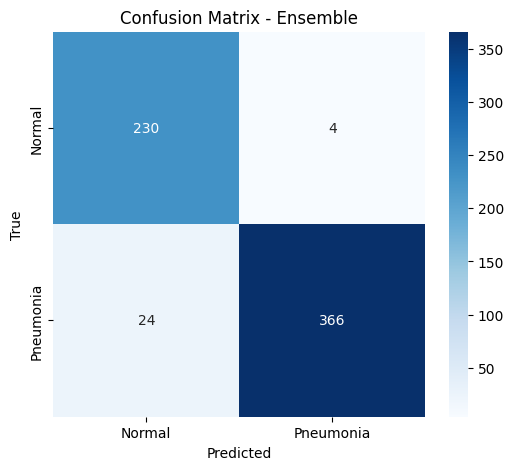


Number of samples improved by ensemble: 116
Sample filenames improved: ['IM-0011-0001-0002.jpeg', 'IM-0016-0001.jpeg', 'IM-0019-0001.jpeg', 'IM-0030-0001.jpeg', 'IM-0033-0001-0001.jpeg', 'IM-0033-0001.jpeg', 'IM-0035-0001.jpeg', 'IM-0039-0001.jpeg', 'IM-0079-0001.jpeg', 'IM-0110-0001.jpeg']


In [72]:
import os
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import timm
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- Device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Load Models --------------------
# US Model: ResNet50
resnet_model = models.resnet50(pretrained=False)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth"))
resnet_model = resnet_model.to(device)
resnet_model.eval()

# CXR Model: ViT
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth"))
vit_model = vit_model.to(device)
vit_model.eval()

# -------------------- Transforms --------------------
cxr_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

us_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# -------------------- Classes --------------------
classes = ["Normal", "Pneumonia"]

# -------------------- Ensemble Function --------------------
def ensemble_predict(cxr_path, us_path, w_cxr=0.5, w_us=0.5):
    cxr_img = cxr_transform(Image.open(cxr_path).convert("RGB")).unsqueeze(0).to(device)
    us_img = us_transform(Image.open(us_path).convert("RGB")).unsqueeze(0).to(device)
    
    with torch.no_grad():
        cxr_probs = nn.Softmax(dim=1)(vit_model(cxr_img))
        us_probs = nn.Softmax(dim=1)(resnet_model(us_img))
    
    ensemble_probs = w_cxr * cxr_probs + w_us * us_probs
    pred_class = torch.argmax(ensemble_probs, dim=1).item()
    cxr_pred = torch.argmax(cxr_probs, dim=1).item()
    us_pred = torch.argmax(us_probs, dim=1).item()
    
    return cxr_pred, us_pred, pred_class, cxr_probs.cpu().numpy(), us_probs.cpu().numpy(), ensemble_probs.cpu().numpy()

# -------------------- Prepare Paired Test Data --------------------
cxr_test_paths = []
us_test_paths = []
labels = []

# Paths
cxr_normal_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/NORMAL"
cxr_pneu_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA"
us_normal_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Normal/images"
us_pneu_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Pneumonia/images"

# Normal
cxr_normal_imgs = sorted(os.listdir(cxr_normal_dir))
us_normal_imgs = sorted(os.listdir(us_normal_dir))
for cxr_img, us_img in zip(cxr_normal_imgs, us_normal_imgs):
    cxr_test_paths.append(os.path.join(cxr_normal_dir, cxr_img))
    us_test_paths.append(os.path.join(us_normal_dir, us_img))
    labels.append(0)

# Pneumonia
cxr_pneu_imgs = sorted(os.listdir(cxr_pneu_dir))
us_pneu_imgs = sorted(os.listdir(us_pneu_dir))
for cxr_img, us_img in zip(cxr_pneu_imgs, us_pneu_imgs):
    cxr_test_paths.append(os.path.join(cxr_pneu_dir, cxr_img))
    us_test_paths.append(os.path.join(us_pneu_dir, us_img))
    labels.append(1)

# -------------------- Run Evaluation --------------------
cxr_preds, us_preds, ensemble_preds = [], [], []
improved_samples = []

for i, (cxr_path, us_path) in enumerate(zip(cxr_test_paths, us_test_paths)):
    cxr_pred, us_pred, ensemble_pred, cxr_prob, us_prob, ensemble_prob = ensemble_predict(cxr_path, us_path)
    
    cxr_preds.append(cxr_pred)
    us_preds.append(us_pred)
    ensemble_preds.append(ensemble_pred)
    
    # Check improvement: ensemble correct while both individual wrong
    if ensemble_pred == labels[i] and (cxr_pred != labels[i] or us_pred != labels[i]):
        improved_samples.append(os.path.basename(cxr_path))

# -------------------- Metrics --------------------
print("==== CXR Model ====")
print(classification_report(labels, cxr_preds, target_names=classes))
print("Accuracy:", accuracy_score(labels, cxr_preds))

print("\n==== US Model ====")
print(classification_report(labels, us_preds, target_names=classes))
print("Accuracy:", accuracy_score(labels, us_preds))

print("\n==== Ensemble (CXR + US) ====")
print(classification_report(labels, ensemble_preds, target_names=classes))
print("Accuracy:", accuracy_score(labels, ensemble_preds))

# -------------------- Confusion Matrix --------------------
cm = confusion_matrix(labels, ensemble_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Ensemble")
plt.show()

# -------------------- Improved Samples --------------------
print(f"\nNumber of samples improved by ensemble: {len(improved_samples)}")
print("Sample filenames improved:", improved_samples[:10])  # show first 10


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


==== Ensemble (CXR + US) ====
              precision    recall  f1-score   support

      Normal       0.91      0.98      0.94       234
   Pneumonia       0.99      0.94      0.96       390

    accuracy                           0.96       624
   macro avg       0.95      0.96      0.95       624
weighted avg       0.96      0.96      0.96       624

Accuracy: 0.9551282051282052


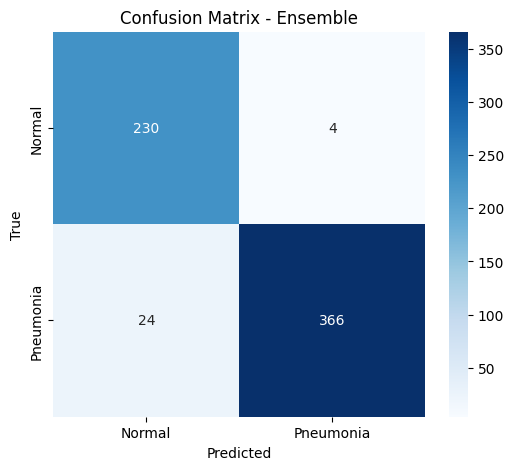


Number of samples improved by ensemble: 116
Sample filenames improved: ['IM-0011-0001-0002.jpeg', 'IM-0016-0001.jpeg', 'IM-0019-0001.jpeg', 'IM-0030-0001.jpeg', 'IM-0033-0001-0001.jpeg', 'IM-0033-0001.jpeg', 'IM-0035-0001.jpeg', 'IM-0039-0001.jpeg', 'IM-0079-0001.jpeg', 'IM-0110-0001.jpeg']


In [73]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import timm

# -------------------- Device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Load Models --------------------
# ResNet50 (Ultrasound)
resnet_model = models.resnet50(pretrained=False)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model.to(device).eval()

# ViT (CXR)
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model.to(device).eval()

# -------------------- Transforms --------------------
cxr_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

us_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# -------------------- Classes --------------------
classes = ["Normal", "Pneumonia"]

# -------------------- Ensemble Function --------------------
def ensemble_predict(cxr_path, us_path, w_cxr=0.5, w_us=0.5):
    cxr_img = cxr_transform(Image.open(cxr_path).convert("RGB")).unsqueeze(0).to(device)
    us_img = us_transform(Image.open(us_path).convert("RGB")).unsqueeze(0).to(device)
    
    with torch.no_grad():
        cxr_probs = F.softmax(vit_model(cxr_img), dim=1)
        us_probs = F.softmax(resnet_model(us_img), dim=1)
    
    ensemble_probs = w_cxr * cxr_probs + w_us * us_probs
    pred_class = torch.argmax(ensemble_probs, dim=1).item()
    return pred_class, cxr_probs.cpu().numpy(), us_probs.cpu().numpy(), ensemble_probs.cpu().numpy()

# -------------------- Prepare Paired Test Data --------------------
def prepare_test_pairs(cxr_normal_dir, cxr_pneu_dir, us_normal_dir, us_pneu_dir):
    cxr_paths, us_paths, labels = [], [], []

    # Normal
    cxr_imgs = sorted(os.listdir(cxr_normal_dir))
    us_imgs = sorted(os.listdir(us_normal_dir))
    for cxr_img, us_img in zip(cxr_imgs, us_imgs):
        cxr_paths.append(os.path.join(cxr_normal_dir, cxr_img))
        us_paths.append(os.path.join(us_normal_dir, us_img))
        labels.append(0)
        
    # Pneumonia
    cxr_imgs = sorted(os.listdir(cxr_pneu_dir))
    us_imgs = sorted(os.listdir(us_pneu_dir))
    for cxr_img, us_img in zip(cxr_imgs, us_imgs):
        cxr_paths.append(os.path.join(cxr_pneu_dir, cxr_img))
        us_paths.append(os.path.join(us_pneu_dir, us_img))
        labels.append(1)
        
    return cxr_paths, us_paths, labels

# Example paths (update according to your dataset)
cxr_normal_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/NORMAL"
cxr_pneu_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA"
us_normal_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Normal/images"
us_pneu_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Pneumonia/images"

cxr_test_paths, us_test_paths, labels = prepare_test_pairs(cxr_normal_dir, cxr_pneu_dir, us_normal_dir, us_pneu_dir)

# -------------------- Run Ensemble Evaluation --------------------
ensemble_preds = []
improved_samples = []

for i, (cxr_path, us_path) in enumerate(zip(cxr_test_paths, us_test_paths)):
    pred, cxr_prob, us_prob, ens_prob = ensemble_predict(cxr_path, us_path, w_cxr=0.5, w_us=0.5)
    ensemble_preds.append(pred)
    
    # check improvement
    cxr_pred = np.argmax(cxr_prob)
    us_pred = np.argmax(us_prob)
    if pred == labels[i] and (cxr_pred != labels[i] or us_pred != labels[i]):
        improved_samples.append(os.path.basename(cxr_path))

# -------------------- Metrics --------------------
print("==== Ensemble (CXR + US) ====")
print(classification_report(labels, ensemble_preds, target_names=classes))
print("Accuracy:", accuracy_score(labels, ensemble_preds))

cm = confusion_matrix(labels, ensemble_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Ensemble")
plt.show()

print(f"\nNumber of samples improved by ensemble: {len(improved_samples)}")
print("Sample filenames improved:", improved_samples[:10])


==== Ensemble (CXR + US) ====
              precision    recall  f1-score   support

      Normal       0.91      0.98      0.94       234
   Pneumonia       0.99      0.94      0.96       390

    accuracy                           0.96       624
   macro avg       0.95      0.96      0.95       624
weighted avg       0.96      0.96      0.96       624

Accuracy: 0.9551282051282052


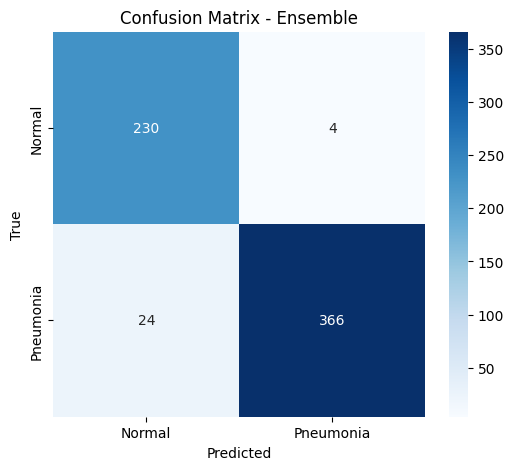

In [75]:
# -------------------- Metrics --------------------
print("==== Ensemble (CXR + US) ====")
print(classification_report(labels, ensemble_preds, target_names=classes))
print("Accuracy:", accuracy_score(labels, ensemble_preds))

# Confusion Matrix
cm = confusion_matrix(labels, ensemble_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Ensemble")

# Save as PNG
plt.savefig("/kaggle/working/confusion_matrix_ensemble.png", bbox_inches='tight', dpi=300)
plt.show()




✅ Saved sample predictions figure as ensemble_samples.png


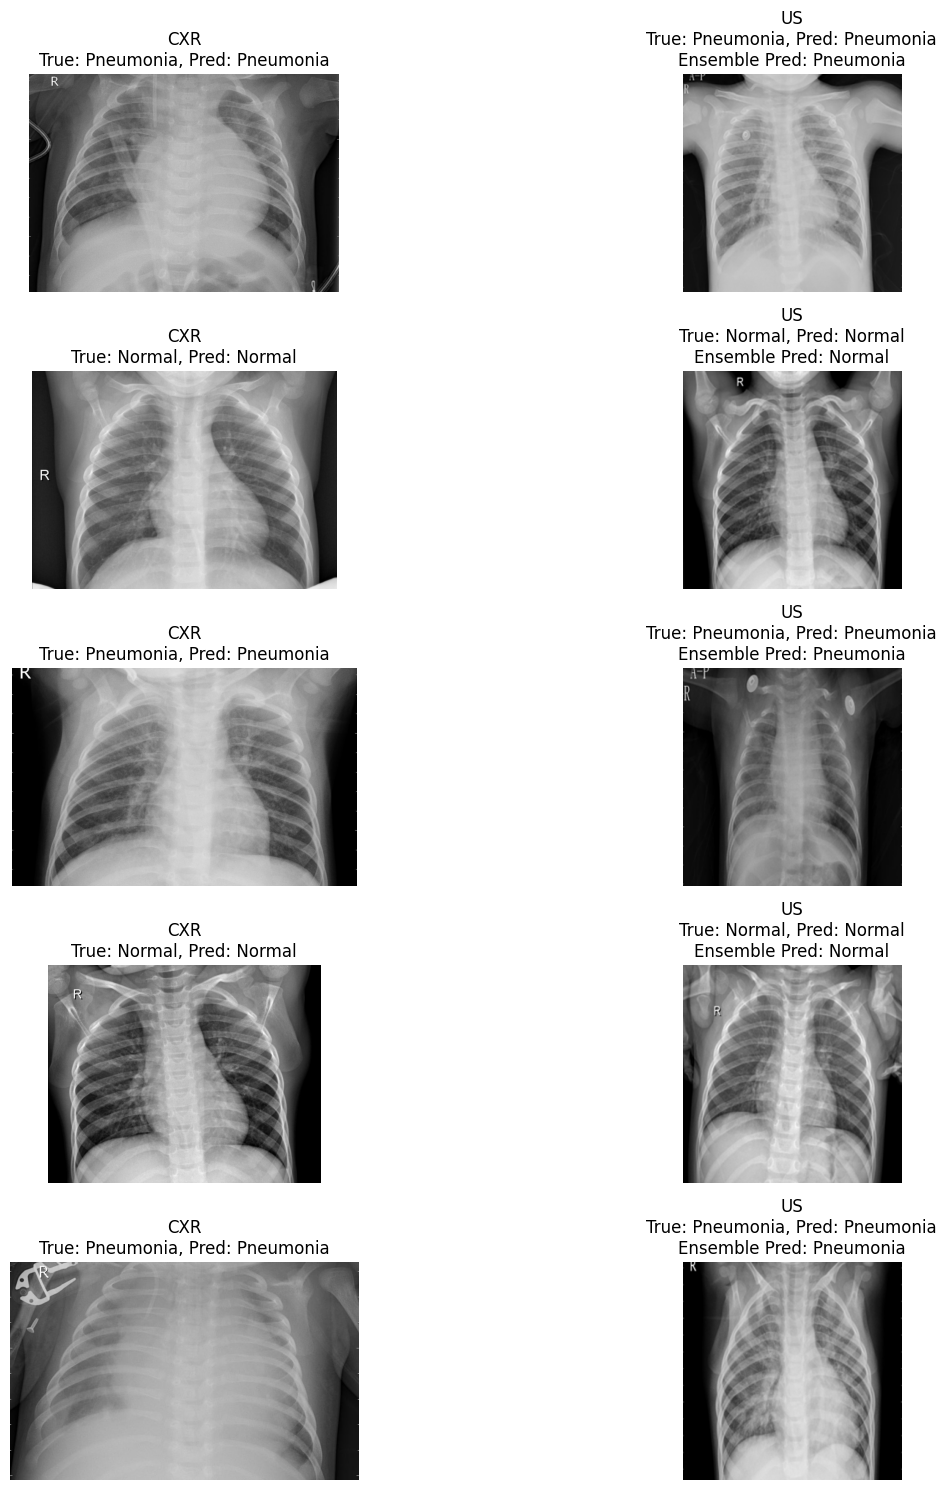

In [77]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# -------------------- Sample Visualization Function --------------------
def show_samples_ensemble(cxr_paths, us_paths, labels, num_samples=5, w_cxr=0.5, w_us=0.5, save_path="ensemble_samples.png"):
    """
    Display random samples with CXR, US, and Ensemble predictions.
    """
    sample_indices = random.sample(range(len(labels)), num_samples)
    
    plt.figure(figsize=(15, num_samples*3))
    
    for i, idx in enumerate(sample_indices):
        cxr_path = cxr_paths[idx]
        us_path = us_paths[idx]
        true_label = labels[idx]
        
        # Run ensemble prediction
        pred, cxr_prob, us_prob, ens_prob = ensemble_predict(cxr_path, us_path, w_cxr=w_cxr, w_us=w_us)
        
        # Load images
        cxr_img = Image.open(cxr_path).convert("RGB")
        us_img = Image.open(us_path).convert("RGB")
        
        # Plot CXR
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(cxr_img)
        plt.axis('off')
        plt.title(f"CXR\nTrue: {classes[true_label]}, Pred: {classes[np.argmax(cxr_prob)]}")
        
        # Plot US
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(us_img)
        plt.axis('off')
        plt.title(f"US\nTrue: {classes[true_label]}, Pred: {classes[np.argmax(us_prob)]}\nEnsemble Pred: {classes[pred]}")
    
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"✅ Saved sample predictions figure as {save_path}")
    plt.show()

# -------------------- Usage --------------------
show_samples_ensemble(cxr_test_paths, us_test_paths, labels, num_samples=5, w_cxr=0.5, w_us=0.5)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


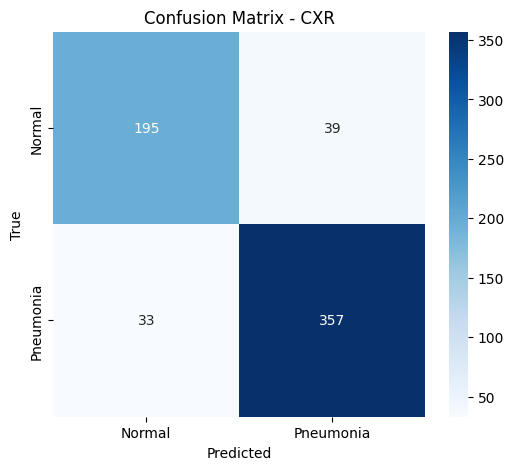

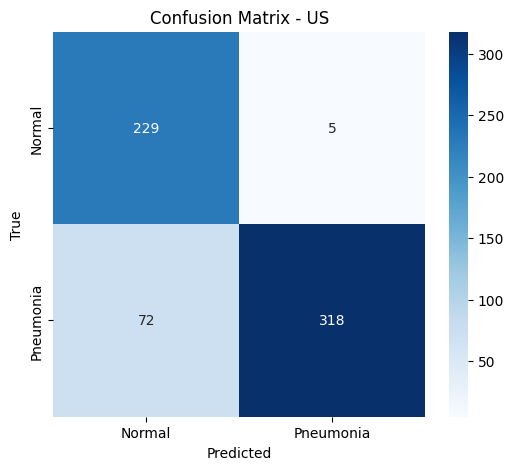

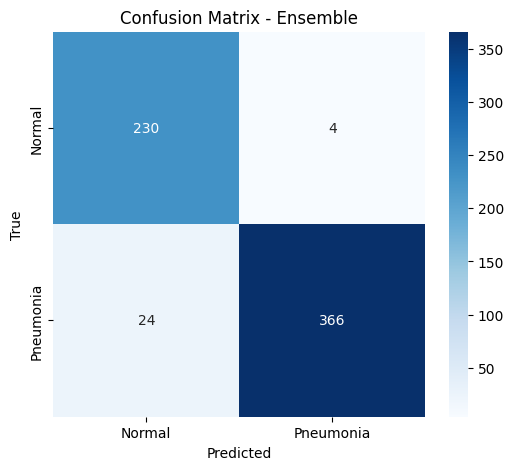

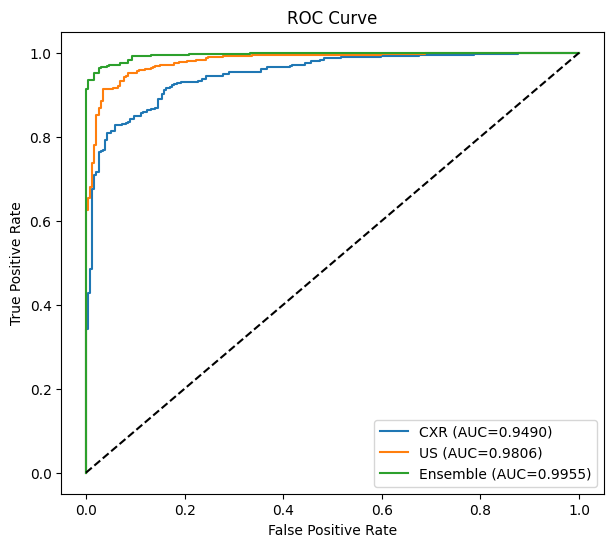

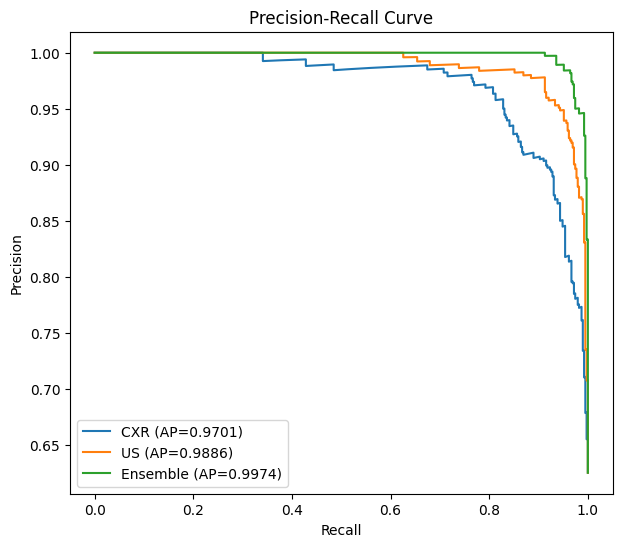

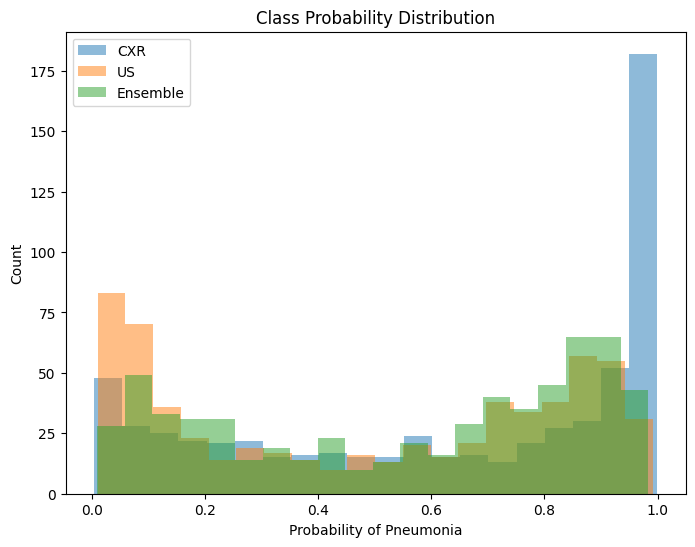

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/IM-0011-0001-0002.jpeg'

<Figure size 1500x500 with 0 Axes>

In [80]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_curve

# -------------------- Device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Load Models --------------------
# ResNet50 (Ultrasound)
resnet_model = models.resnet50(pretrained=False)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model.load_state_dict(torch.load("best_covid19_resnet50.pth", map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()

# ViT (CXR)
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/kaggle/working/pediatric_pneumonia_vit.pth", map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()

# -------------------- Transforms --------------------
cxr_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
us_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------- Classes --------------------
classes = ["Normal", "Pneumonia"]

# -------------------- Ensemble Prediction --------------------
def ensemble_predict(cxr_path, us_path, w_cxr=0.5, w_us=0.5):
    cxr_img = cxr_transform(Image.open(cxr_path).convert("RGB")).unsqueeze(0).to(device)
    us_img = us_transform(Image.open(us_path).convert("RGB")).unsqueeze(0).to(device)
    
    with torch.no_grad():
        cxr_probs = F.softmax(vit_model(cxr_img), dim=1)
        us_probs = F.softmax(resnet_model(us_img), dim=1)
    
    ensemble_probs = w_cxr * cxr_probs + w_us * us_probs
    pred_class = torch.argmax(ensemble_probs, dim=1).item()
    cxr_pred = torch.argmax(cxr_probs, dim=1).item()
    us_pred = torch.argmax(us_probs, dim=1).item()
    
    return cxr_pred, us_pred, pred_class, cxr_probs.cpu().numpy(), us_probs.cpu().numpy(), ensemble_probs.cpu().numpy()

# -------------------- Prepare Paired Test Data --------------------
cxr_test_paths, us_test_paths, labels = [], [], []

cxr_normal_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/NORMAL"
cxr_pneu_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA"
us_normal_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Normal/images"
us_pneu_dir = "/kaggle/input/covid19-data/COVID-19_Radiography_Dataset/Pneumonia/images"

# Normal
for cxr_img, us_img in zip(sorted(os.listdir(cxr_normal_dir)), sorted(os.listdir(us_normal_dir))):
    cxr_test_paths.append(os.path.join(cxr_normal_dir, cxr_img))
    us_test_paths.append(os.path.join(us_normal_dir, us_img))
    labels.append(0)
# Pneumonia
for cxr_img, us_img in zip(sorted(os.listdir(cxr_pneu_dir)), sorted(os.listdir(us_pneu_dir))):
    cxr_test_paths.append(os.path.join(cxr_pneu_dir, cxr_img))
    us_test_paths.append(os.path.join(us_pneu_dir, us_img))
    labels.append(1)

# -------------------- Run Predictions --------------------
cxr_preds, us_preds, ensemble_preds = [], [], []
cxr_probs_list, us_probs_list, ensemble_probs_list = [], [], []
improved_samples = []

for i, (cxr_path, us_path) in enumerate(zip(cxr_test_paths, us_test_paths)):
    cxr_pred, us_pred, ensemble_pred, cxr_prob, us_prob, ensemble_prob = ensemble_predict(cxr_path, us_path)
    cxr_preds.append(cxr_pred)
    us_preds.append(us_pred)
    ensemble_preds.append(ensemble_pred)
    cxr_probs_list.append(cxr_prob)
    us_probs_list.append(us_prob)
    ensemble_probs_list.append(ensemble_prob)
    
    # Check improvement
    if ensemble_pred == labels[i] and (cxr_pred != labels[i] or us_pred != labels[i]):
        improved_samples.append((os.path.basename(cxr_path), os.path.basename(us_path)))

# -------------------- Confusion Matrices --------------------
def plot_confusion(cm, title, filename):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

plot_confusion(confusion_matrix(labels, cxr_preds), "Confusion Matrix - CXR", "/kaggle/working/cm_cxr.png")
plot_confusion(confusion_matrix(labels, us_preds), "Confusion Matrix - US", "/kaggle/working/cm_us.png")
plot_confusion(confusion_matrix(labels, ensemble_preds), "Confusion Matrix - Ensemble", "/kaggle/working/cm_ensemble.png")

# -------------------- ROC Curve --------------------
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(labels, classes=[0,1])
cxr_probs_arr = np.vstack(cxr_probs_list)[:,1]
us_probs_arr = np.vstack(us_probs_list)[:,1]
ensemble_probs_arr = np.vstack(ensemble_probs_list)[:,1]

plt.figure(figsize=(7,6))
fpr, tpr, _ = roc_curve(y_true_bin, cxr_probs_arr)
plt.plot(fpr, tpr, label=f"CXR (AUC={auc(fpr, tpr):.4f})")
fpr, tpr, _ = roc_curve(y_true_bin, us_probs_arr)
plt.plot(fpr, tpr, label=f"US (AUC={auc(fpr, tpr):.4f})")
fpr, tpr, _ = roc_curve(y_true_bin, ensemble_probs_arr)
plt.plot(fpr, tpr, label=f"Ensemble (AUC={auc(fpr, tpr):.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("/kaggle/working/roc_curve.png", bbox_inches='tight', dpi=300)
plt.show()

# -------------------- Precision-Recall Curve --------------------
plt.figure(figsize=(7,6))
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true_bin, cxr_probs_arr)
plt.plot(recall, precision, label=f"CXR (AP={average_precision_score(y_true_bin, cxr_probs_arr):.4f})")
precision, recall, _ = precision_recall_curve(y_true_bin, us_probs_arr)
plt.plot(recall, precision, label=f"US (AP={average_precision_score(y_true_bin, us_probs_arr):.4f})")
precision, recall, _ = precision_recall_curve(y_true_bin, ensemble_probs_arr)
plt.plot(recall, precision, label=f"Ensemble (AP={average_precision_score(y_true_bin, ensemble_probs_arr):.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("/kaggle/working/pr_curve.png", bbox_inches='tight', dpi=300)
plt.show()

# -------------------- Probability Distribution --------------------
plt.figure(figsize=(8,6))
plt.hist(cxr_probs_arr, bins=20, alpha=0.5, label="CXR")
plt.hist(us_probs_arr, bins=20, alpha=0.5, label="US")
plt.hist(ensemble_probs_arr, bins=20, alpha=0.5, label="Ensemble")
plt.xlabel("Probability of Pneumonia")
plt.ylabel("Count")
plt.title("Class Probability Distribution")
plt.legend()
plt.savefig("/kaggle/working/prob_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

# -------------------- Top Improved Samples --------------------
import matplotlib.image as mpimg

num_samples = min(10, len(improved_samples))
plt.figure(figsize=(15, 5))
for i, (cxr_file, us_file) in enumerate(improved_samples[:num_samples]):
    cxr_img = mpimg.imread(os.path.join(cxr_normal_dir if "NORMAL" in cxr_file else cxr_pneu_dir, cxr_file))
    us_img = mpimg.imread(os.path.join(us_normal_dir if "Normal" in us_file else us_pneu_dir, us_file))
    
    plt.subplot(2,num_samples,i+1)
    plt.imshow(cxr_img)
    plt.axis('off')
    plt.title(f"CXR: {cxr_file}")
    
    plt.subplot(2,num_samples,num_samples+i+1)
    plt.imshow(us_img)
    plt.axis('off')
    plt.title(f"US: {us_file}")
plt.tight_layout()
plt.savefig("/kaggle/working/improved_samples.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"Total improved samples: {len(improved_samples)}")
